# Compare Inversion Calls Across Treatments
What would be interesting to see is the inversion-calling performance in linked reads across inversion sizes and depths. Since we already created the assessment tables from the individual size-class data exploration, we can read those in without having to reprocess those data.

In [23]:
library(ggplot2)
library(dplyr)
library(ggh4x)
options(warn = -1)

Read in the linked-read variant assessment

In [53]:
.assess <- read.csv("assess_called_sv/linkedread.sv.assessment", header = T)
.assess$zygosity <- gsub("hom", "homozygote", .assess$zygosity)
.assess$zygosity <- gsub("het", "heterozygote", .assess$zygosity)
head(.assess)

,contig,inversion,id,depth,sample,size,simulated,zygosity,assessment,position_start,position_end,technology
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<chr>,<int>,<int>,<chr>
1,2L,1,1,0.5,11,small,TRUE,homozygote,false negative,3193196,3214221,linkedread
2,2L,1,1,2.0,11,small,TRUE,homozygote,true positive,3193196,3214221,linkedread
3,2L,1,1,5.0,11,small,TRUE,homozygote,true positive,3193196,3214221,linkedread
4,2L,1,1,10.0,11,small,TRUE,homozygote,true positive,3193196,3214221,linkedread
5,2L,1,1,20.0,11,small,TRUE,homozygote,true positive,3193196,3214221,linkedread
6,2L,1,1,0.5,1,small,TRUE,homozygote,false negative,3193196,3214221,linkedread


Read in the long-read variant assessment

In [ ]:
longread <- read.csv("longread_workflow/longread.sv.assessment", header = T)
longread$zygosity <- gsub("hom", "homozygote", longread$zygosity)
longread$zygosity <- gsub("het", "heterozygote", longread$zygosity)

head(longread)

,sample,contig,position_start,position_end,size,present,state,assessment,depth,platform
,<chr>,<chr>,<int>,<int>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<chr>
1,sample_01,2L,11529165,15060030,large,TRUE,hom,false negative,0.5,pacbio
2,sample_01,2L,11529165,15060030,large,TRUE,hom,false negative,0.5,ontlong
3,sample_01,2L,11529165,15060030,large,TRUE,hom,false negative,0.5,ontshort
4,sample_01,2L,11529165,15060030,large,TRUE,hom,true positive,2.0,pacbio
5,sample_01,2L,11529165,15060030,large,TRUE,hom,true positive,2.0,ontlong
6,sample_01,2L,11529165,15060030,large,TRUE,hom,false negative,2.0,ontshort


Ok so maybe I wasn't as consistent with naming as I could have been between the linked-read and long-read workflows, but let's unify that here. First by renaming the columns in the long-read data to match the linked-read data, then to convert samples to integers.

In [26]:
longread <- rename(longread, "simulated" = present, "zygosity" = state, "technology" = platform)
longread$sample <- as.integer(gsub("sample_", "", longread$sample))
head(longread)

,sample,contig,position_start,position_end,size,simulated,zygosity,assessment,depth,technology
,<int>,<chr>,<int>,<int>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<chr>
1,1,2L,11529165,15060030,large,TRUE,hom,false negative,0.5,pacbio
2,1,2L,11529165,15060030,large,TRUE,hom,false negative,0.5,ontlong
3,1,2L,11529165,15060030,large,TRUE,hom,false negative,0.5,ontshort
4,1,2L,11529165,15060030,large,TRUE,hom,true positive,2.0,pacbio
5,1,2L,11529165,15060030,large,TRUE,hom,true positive,2.0,ontlong
6,1,2L,11529165,15060030,large,TRUE,hom,false negative,2.0,ontshort


Next we keep only the relevant columns from the linked-read data (1, 4 through 9, and 12) and reorganize the columns in the long-read data to match.

In [27]:
assess <- rbind(
    .assess[, c(1, 4:9, 12)],
    longread[, c(2,9,1,5:8, 10)]
)

Let's also make some of the columns factors

In [28]:
assess$depth <- as.factor(assess$depth)
assess$size <- factor(assess$size, ordered = T, levels = c("small","medium","large","xl"))
assess$technology <- factor(assess$technology, ordered = T, levels = c("linkedread", "ontshort", "ontlong", "pacbio"))
assess$zygosity <- as.factor(assess$zygosity)
assess$assessment <- as.factor(assess$assessment)
head(assess, 10)

,contig,depth,sample,size,simulated,zygosity,assessment,technology
,<chr>,<fct>,<int>,<ord>,<lgl>,<fct>,<fct>,<ord>
1,2L,0.5,11,small,TRUE,hom,false negative,linkedread
2,2L,2,11,small,TRUE,hom,true positive,linkedread
3,2L,5,11,small,TRUE,hom,true positive,linkedread
4,2L,10,11,small,TRUE,hom,true positive,linkedread
5,2L,20,11,small,TRUE,hom,true positive,linkedread
6,2L,0.5,1,small,TRUE,hom,false negative,linkedread
7,2L,2,1,small,TRUE,hom,true positive,linkedread
8,2L,5,1,small,TRUE,hom,true positive,linkedread
9,2L,10,1,small,TRUE,hom,true positive,linkedread


## Sample-level Calling
### Prepare the Data
It would probably make sense to collapse these data somewhat to show a representation of true positives vs false negatives (as a ratio) across depths (x axis) and faceted for hom/het in the non-pooled data. We will also remove inversions that weren't simulated for a sample b/c we aren't interested in true negatives (since there were no false positives).

In [29]:
samples <- assess[assess$sample != 11 & assess$simulated,]

samples <- group_by(samples, size, depth, zygosity, assessment, technology) %>%
    summarize(count = n()) %>% ungroup()

head(samples)

`summarise()` has grouped output by 'size', 'depth', 'zygosity', 'assessment'.
You can override using the `.groups` argument.


size,depth,zygosity,assessment,technology,count
<ord>,<fct>,<fct>,<fct>,<ord>,<int>
small,0.5,het,false negative,linkedread,74
small,0.5,het,false negative,ontshort,74
small,0.5,het,false negative,ontlong,74
small,0.5,het,false negative,pacbio,73
small,0.5,het,true positive,pacbio,1
small,0.5,hom,false negative,linkedread,69


Some of the treatments don't have true positives or false negatives, so we'll need to add in rows with count `0` for those treatments.

In [30]:
# add missing rows with value 0 in the event there were no true positives or false negatives for a treatment
# instantiate empty def
missings <- samples[0,]

for(size in c("small","medium","large","xl")){
    for(depth in levels(samples$depth)){
        for(zyg in c("hom","het")){
            for(tech in c("linkedread", "ontshort", "ontlong", "pacbio")){
                .df <- samples[samples$size == size & samples$depth == depth & samples$zygosity == zyg & samples$technology == tech,]
                if(!("false negative" %in% .df$assessment)){
                    missings[nrow(missings)+1,] <- list(size, depth, zyg,"false negative", tech, 0)
                }
                if(!("true positive" %in% .df$assessment)){
                    missings[nrow(missings)+1,] <- list(size, depth, zyg,"true positive", tech, 0)
                }
            }
        }
    }
}

samples <- rbind(samples,missings) %>% arrange(size, depth, zygosity, technology)
head(samples)

size,depth,zygosity,assessment,technology,count
<ord>,<fct>,<fct>,<fct>,<ord>,<int>
small,0.5,het,false negative,linkedread,74
small,0.5,het,true positive,linkedread,0
small,0.5,het,false negative,ontshort,74
small,0.5,het,true positive,ontshort,0
small,0.5,het,false negative,ontlong,74
small,0.5,het,true positive,ontlong,0


One last thing we'll need to do is convert counts to proportions

In [31]:
samples <- group_by(samples, size, depth, zygosity, technology) %>% mutate(proportion = round(count/sum(count),2))
head(samples)

size,depth,zygosity,assessment,technology,count,proportion
<ord>,<fct>,<fct>,<fct>,<ord>,<int>,<dbl>
small,0.5,het,false negative,linkedread,74,1
small,0.5,het,true positive,linkedread,0,0
small,0.5,het,false negative,ontshort,74,1
small,0.5,het,true positive,ontshort,0,0
small,0.5,het,false negative,ontlong,74,1
small,0.5,het,true positive,ontlong,0,0


Let's also set a color palette for the technology comparisons using the [Arches theme](https://github.com/katiejolly/nationalparkcolors/tree/master) and the Redwoods theme for the depths.

In [32]:
tech_colors <- c(
    "ontshort" = "#9b6981",
    "ontlong" = "#682c37",
    "pacbio" = "#f6955e" ,
    "linkedread" = "#a8cdec"
)

size_colors <- c(
    "#c0c6cf",
    "#a2aab5",
    "#6e7684",
    "#54546c"
)

zygosity_colors <- c(
    "#85a98eff",
    "#7fa9b4ff"
)

### Visualization
We are now interested in seeing how these performed. There are several dimensions to consider here:
- depth
- inversion size
- zygotic state
- sequencing technology

#### Detection between technologies across inversion classes
We'll approach this a few different ways to try to reveal meaningful information. First let's compare how each of the technologies did within a given inversion size class.

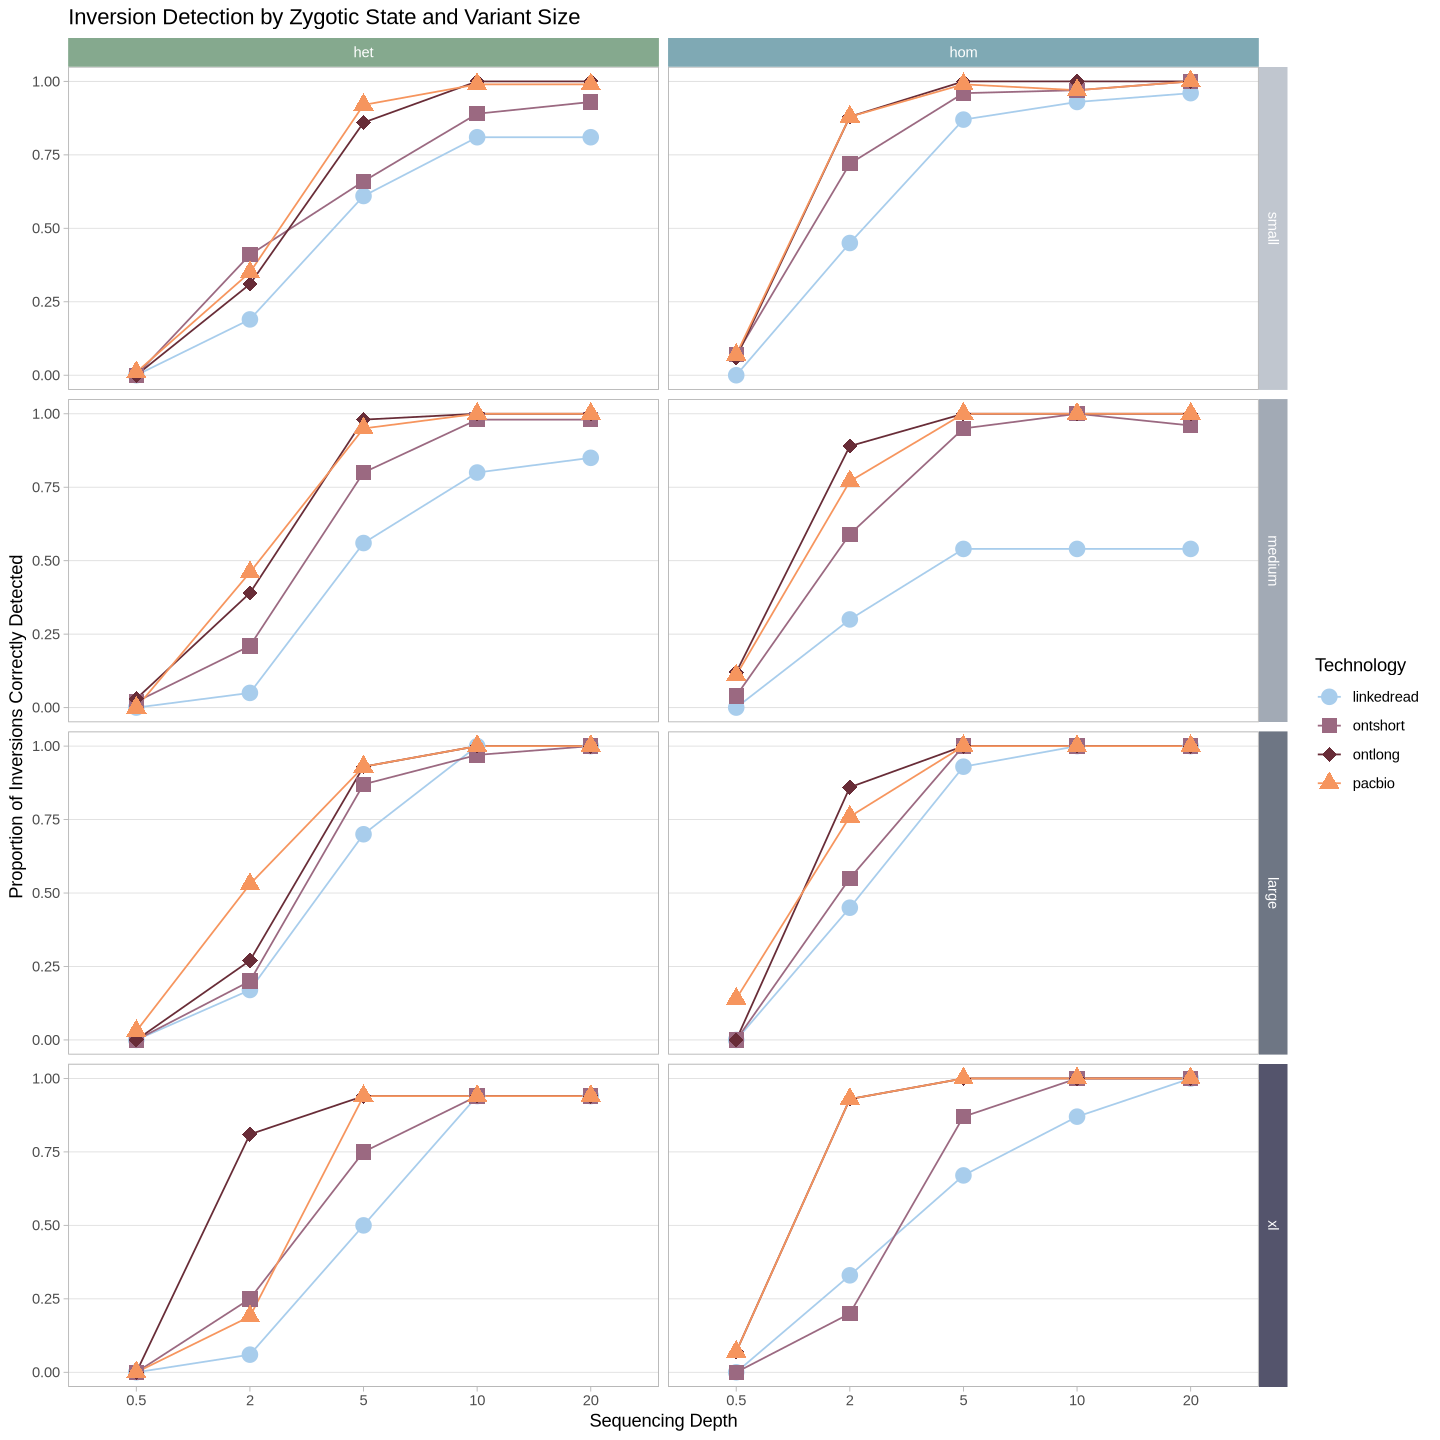

In [33]:
options(repr.plot.width = 12, repr.plot.height = 12)
.strip <- strip_themed(background_x = elem_list_rect(fill = zygosity_colors), background_y = elem_list_rect(fill = size_colors))

filter(samples, assessment == "true positive") %>%
ggplot(aes(x = depth, y = proportion, color = technology, group = technology, shape = technology)) +
    geom_line() +
    geom_point(size = 4) +
    scale_color_manual(values = tech_colors) +
    scale_shape_manual(values = c(19,15,18,17)) +
    theme_light() +
    labs(title = "Inversion Detection by Zygotic State and Variant Size", color = "Technology", shape = "Technology") +
    ylab("Proportion of Inversions Correctly Detected") +
    xlab("Sequencing Depth") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid2(cols = vars(zygosity), rows = vars(size), strip = .strip)

#### Detection between inversion class within technologies
This is effectively the same thing, but it's a more 1:1 comparison across size classes within a given technology.

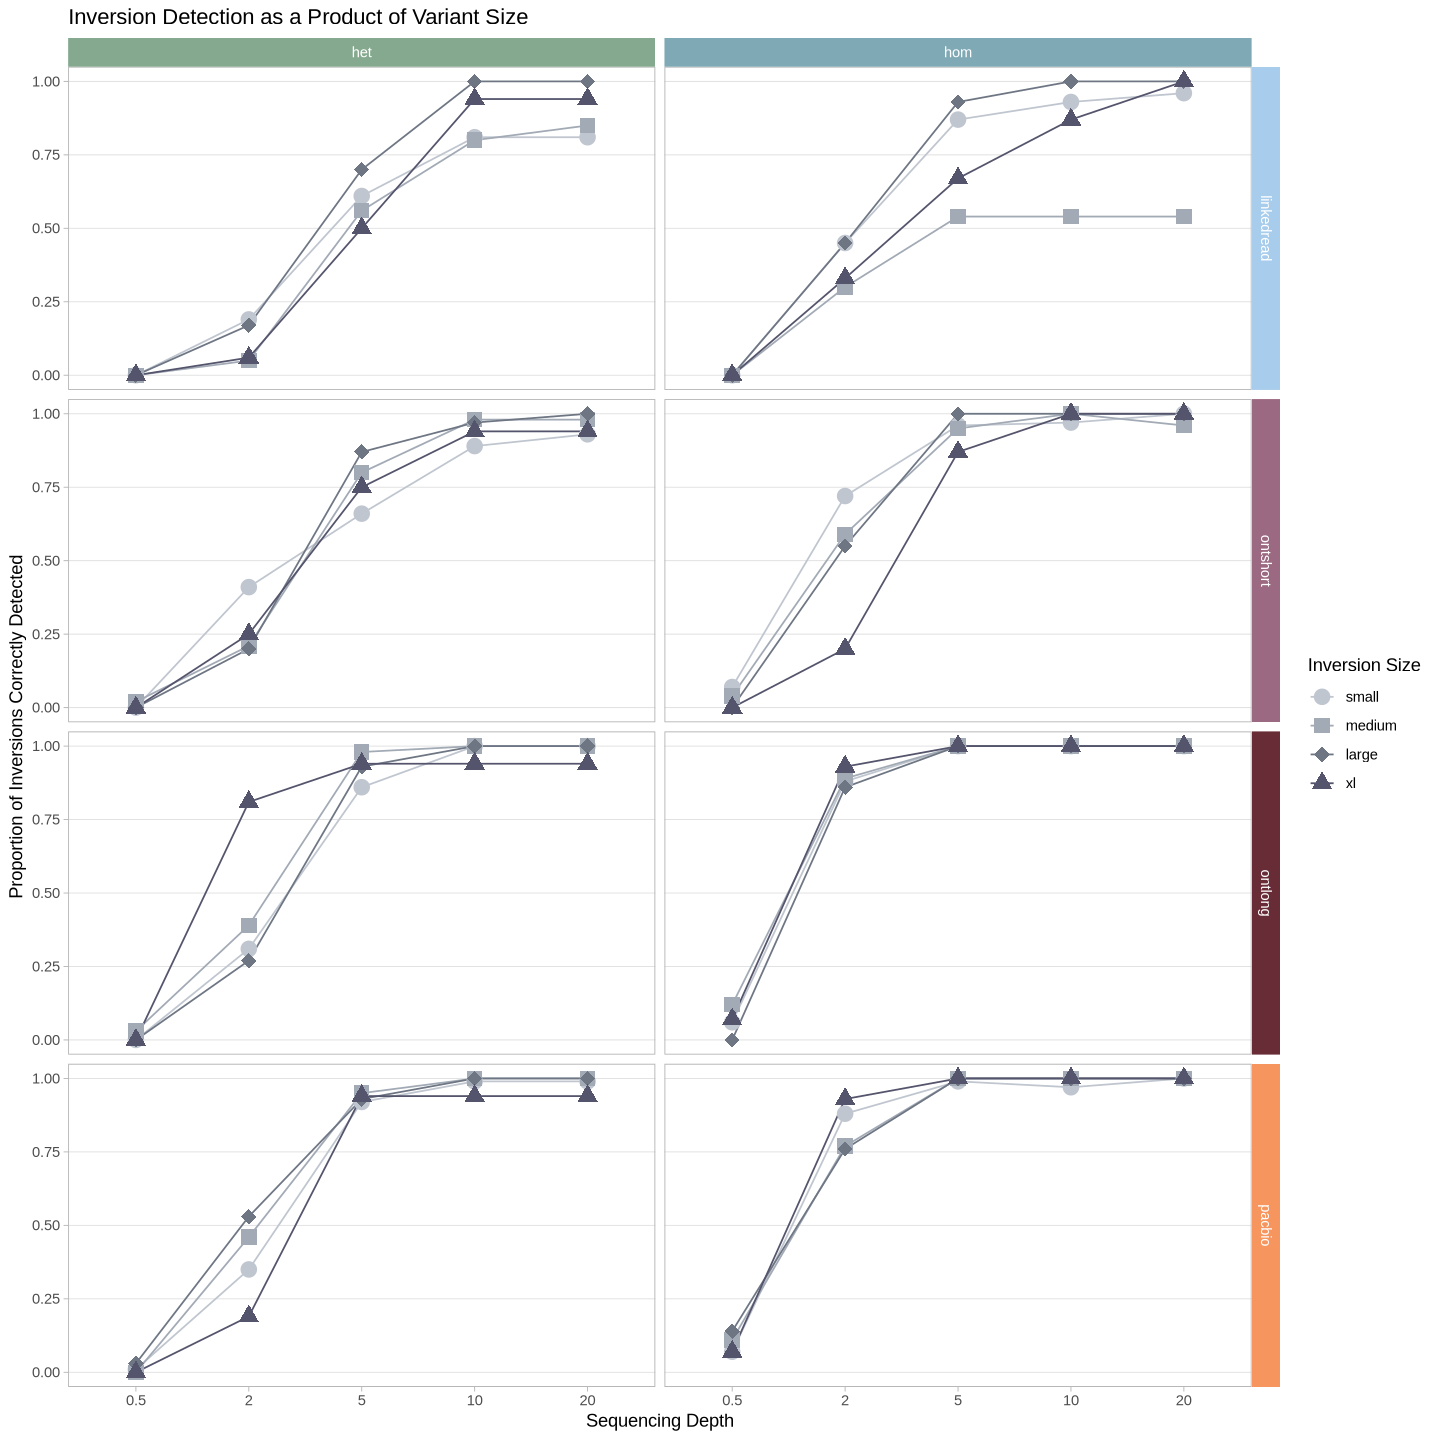

In [34]:
options(repr.plot.width = 12, repr.plot.height = 12)
.strip <- strip_themed(background_x = elem_list_rect(fill = zygosity_colors), background_y = elem_list_rect(fill = tech_colors[c(4,1,2,3)]))

filter(samples, assessment == "true positive") %>%
ggplot(aes(x = depth, y = proportion, color = size, group = size, shape = size)) +
    geom_line() +
    geom_point(size = 4) +
    scale_shape_manual(values = c(19,15,18,17)) +
    scale_color_manual(values = size_colors) +
    theme_light() +
    labs(title = "Inversion Detection as a Product of Variant Size", color = "Inversion Size", shape = "Inversion Size") +
    ylab("Proportion of Inversions Correctly Detected") +
    xlab("Sequencing Depth") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid2(cols = vars(zygosity), rows = vars(technology), strip = .strip)

#### Holistic comparison of technologies
What does it look like when we compare the performance of hom/het within and across technologies for each inversion class?

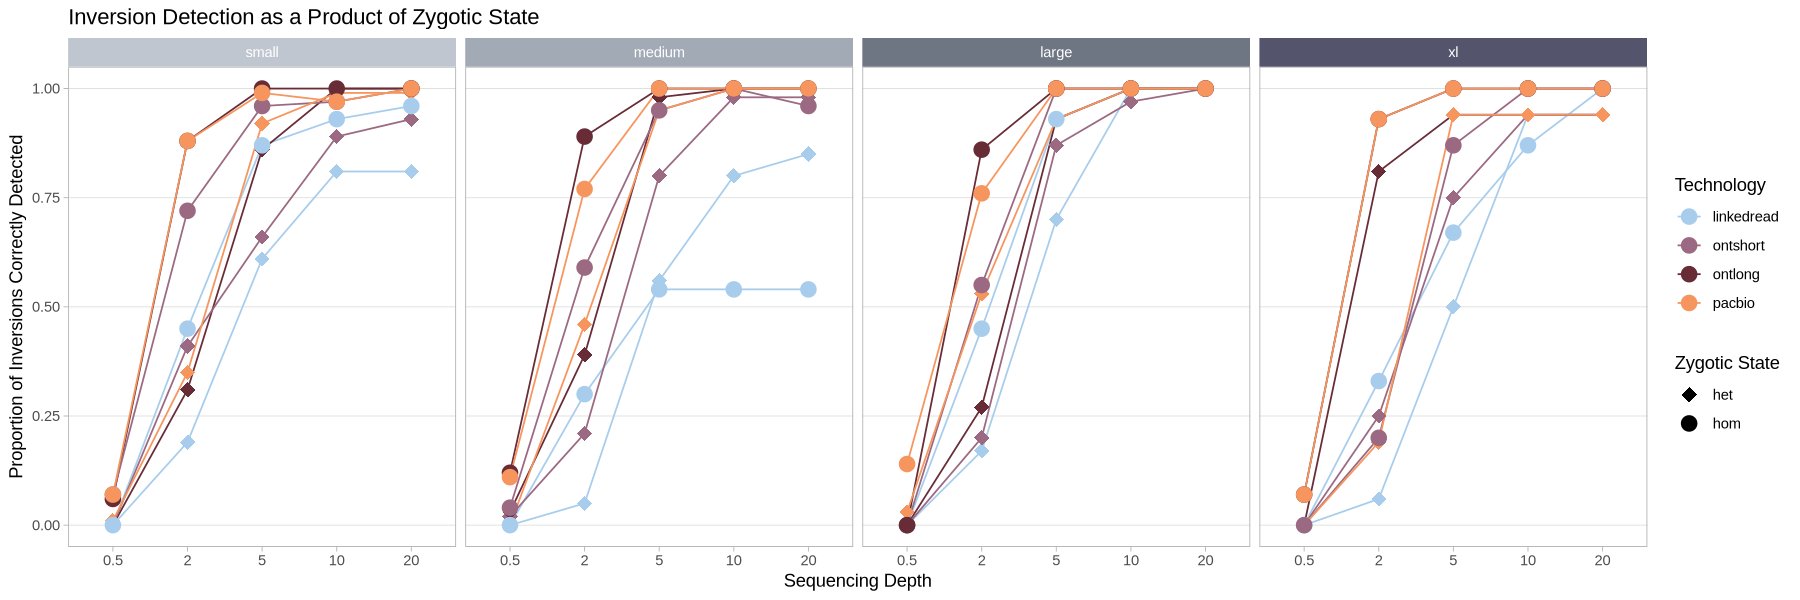

In [35]:
options(repr.plot.width = 15, repr.plot.height = 5)
.strip <- strip_themed(background_x = elem_list_rect(fill = size_colors))

filter(samples, assessment == "true positive") %>%
ggplot(aes(x = depth, y = proportion, color = technology, group = paste(technology, zygosity), shape = zygosity)) +
    geom_line() +
    geom_point(aes(shape = zygosity), size = 4) +
    theme_light() +
    scale_color_manual(values = tech_colors) +
    scale_shape_manual(values = c("hom"= 19,"het" = 18)) +
    labs(title = "Inversion Detection as a Product of Zygotic State", color = "Technology", shape = "Zygotic State") +
    ylab("Proportion of Inversions Correctly Detected") +
    xlab("Sequencing Depth") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid2(cols = vars(size), strip = .strip)

## Pooled Data
Now let's look at the analogous characteristics of the pooled data. It's very important to note here, the comparison is between the **pooled linked-read data** and the **single-sample long-read data**. That is to say, we are interested in seeing if sequencing these 10 samples with each of these technologies yields different results. Above, we show that when structural variants are called for individual samples, linked reads tend to underperform long-reads at each depth. However, if we pool the 10 linked-read samples together, we effectively boost the sequencing depth x10. 

### Data Preparation
We need to filter for pooled samples only. The contig names don't matter so much here as much as "common" or "rare" does,
so we need to rename the contigs and sum their values. For plotting purporses, we'll also want to get a count of the number of inversions for each category so there's an indication of sample size for each treatment.

In [36]:
pooled <- assess[assess$sample == 11 & assess$simulated | assess$technology != "linkedread",]
pooled$treatment <- case_when(
    pooled$contig == "2L" ~ "Common",
    pooled$contig == "2R" ~ "Common",
    pooled$contig == "3L" ~ "Common",
    pooled$contig == "3R" ~ "Rare"
)

pooled <- group_by(pooled, treatment, size, depth, assessment, technology) %>%
    summarize(count = n()) %>%
    group_by(treatment, size, depth, technology) %>%
    mutate(total = sum(count)) %>%
    ungroup() %>%
    arrange(size, depth, technology)

head(pooled)

`summarise()` has grouped output by 'treatment', 'size', 'depth', 'assessment'.
You can override using the `.groups` argument.


treatment,size,depth,assessment,technology,count,total
<chr>,<ord>,<fct>,<fct>,<ord>,<int>,<int>
Common,small,0.5,false negative,linkedread,15,15
Rare,small,0.5,false negative,linkedread,5,5
Common,small,0.5,false negative,ontshort,105,150
Common,small,0.5,true negative,ontshort,40,150
Common,small,0.5,true positive,ontshort,5,150
Rare,small,0.5,false negative,ontshort,33,50


Again, some of the treatments are missing `false negative` or `true positive` rows, so we need to add them with a count of `0`.

In [37]:
# add missing rows with value 0 in the event there were no true positives or false negatives for a treatment
# instantiate empty def
missings <- pooled[0,]

for(.size in c("small","medium","large","xl")){
    for(.depth in levels(pooled$depth)){
        for(.treat in c("Common", "Rare")){
            for(.tech in levels(pooled$technology)){
                .df <- filter(pooled, size == .size,  depth == .depth, treatment == .treat, technology == .tech)
                .tot <- sum(.df$total)
                if(!("false negative" %in% .df$assessment)){
                    missings[nrow(missings)+1,] <- list(.treat, .size, .depth, "false negative", .tech, 0, .tot)
                }
                if(!("true positive" %in% .df$assessment)){
                    missings[nrow(missings)+1,] <- list(.treat, .size, .depth, "true positive", .tech, 0, .tot)
                }
            }
        }
    }
}

pooled <- rbind(pooled,missings) %>% arrange(size, depth, technology, treatment)
head(pooled)

treatment,size,depth,assessment,technology,count,total
<chr>,<ord>,<fct>,<fct>,<ord>,<int>,<int>
Common,small,0.5,false negative,linkedread,15,15
Common,small,0.5,true positive,linkedread,0,15
Rare,small,0.5,false negative,linkedread,5,5
Rare,small,0.5,true positive,linkedread,0,5
Common,small,0.5,false negative,ontshort,105,150
Common,small,0.5,true negative,ontshort,40,150


Lastly, convert the counts to proportions. Let's also rename the depths to properly reflect that with aggregates, the depth is actually 10X higher. Seems silly to have to do `as.numeric(as.character())`, but if you don't convert it to a `Character` first, `0.5` gets misinterpereted as `1`.

In [38]:
pooled <- group_by(pooled, treatment, size, depth, technology) %>% mutate(proportion = round(count/sum(count),2))
#agg_depths <- paste0(as.numeric(as.character(pooled$depth)) * 10, " (", pooled$depth, ")")
#pooled$agg_depth <- factor(agg_depths, levels = unique(agg_depths))
head(pooled)

treatment,size,depth,assessment,technology,count,total,proportion
<chr>,<ord>,<fct>,<fct>,<ord>,<int>,<int>,<dbl>
Common,small,0.5,false negative,linkedread,15,15,1.00
Common,small,0.5,true positive,linkedread,0,15,0.00
Rare,small,0.5,false negative,linkedread,5,5,1.00
Rare,small,0.5,true positive,linkedread,0,5,0.00
Common,small,0.5,false negative,ontshort,105,150,0.70
Common,small,0.5,true negative,ontshort,40,150,0.27


It would behoove us to show a more informative X-axis that has both the single-sample sequencing depth and the pooled aggregate depth, so let's set that up here.

In [45]:
depth_labels <- c("0.5X (5X)", "2X (10X)", "5X (50X)", "10X (100X)", "20X (200X)")
freq_colors <- c(
    "#45865fff",
    "#8ebba1ff"
)

### Visualization
#### Detection by frequency

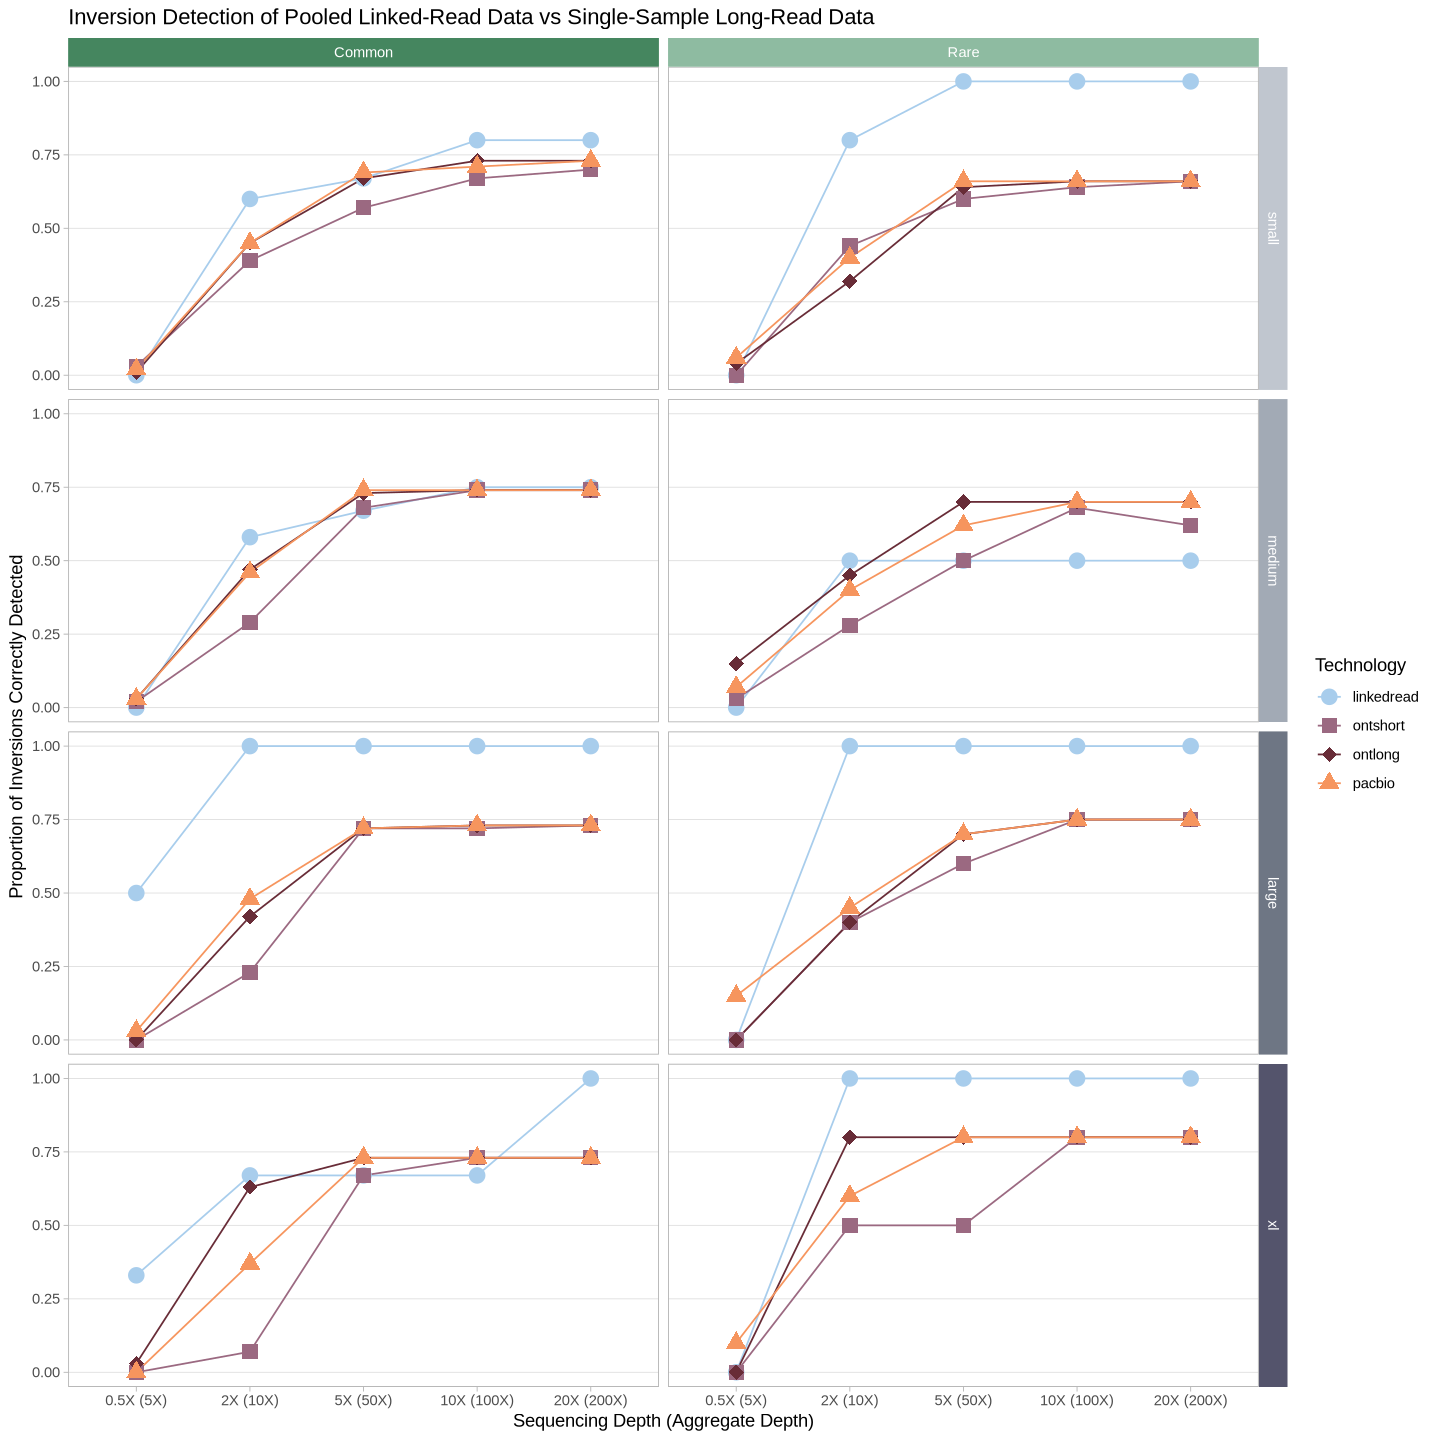

In [46]:
options(repr.plot.width = 12, repr.plot.height = 12)
.strip <- strip_themed(background_x = elem_list_rect(fill = freq_colors), background_y = elem_list_rect(fill = size_colors))

filter(pooled, assessment == "true positive") %>%
ggplot(aes(x = depth, y = proportion, color = technology, group = technology, shape = technology)) +
    geom_line() +
    geom_point(size = 4) +
    scale_shape_manual(values = c(19,15,18,17)) +
    scale_x_discrete(labels = depth_labels) +
    scale_color_manual(values = tech_colors) +
    theme_light() +
    labs(title = "Inversion Detection of Pooled Linked-Read Data vs Single-Sample Long-Read Data", color = "Technology", shape = "Technology") +
    ylab("Proportion of Inversions Correctly Detected") +
    xlab("Sequencing Depth (Aggregate Depth)") +
    theme(
        panel.grid.minor.y = element_blank(),
        panel.grid.major.x = element_blank()
    ) +
    facet_grid2(cols = vars(treatment), rows = vars(size), strip = .strip)

#### True Positives Across Inversion Size Classes
Consolidate views of just true positives across treatments

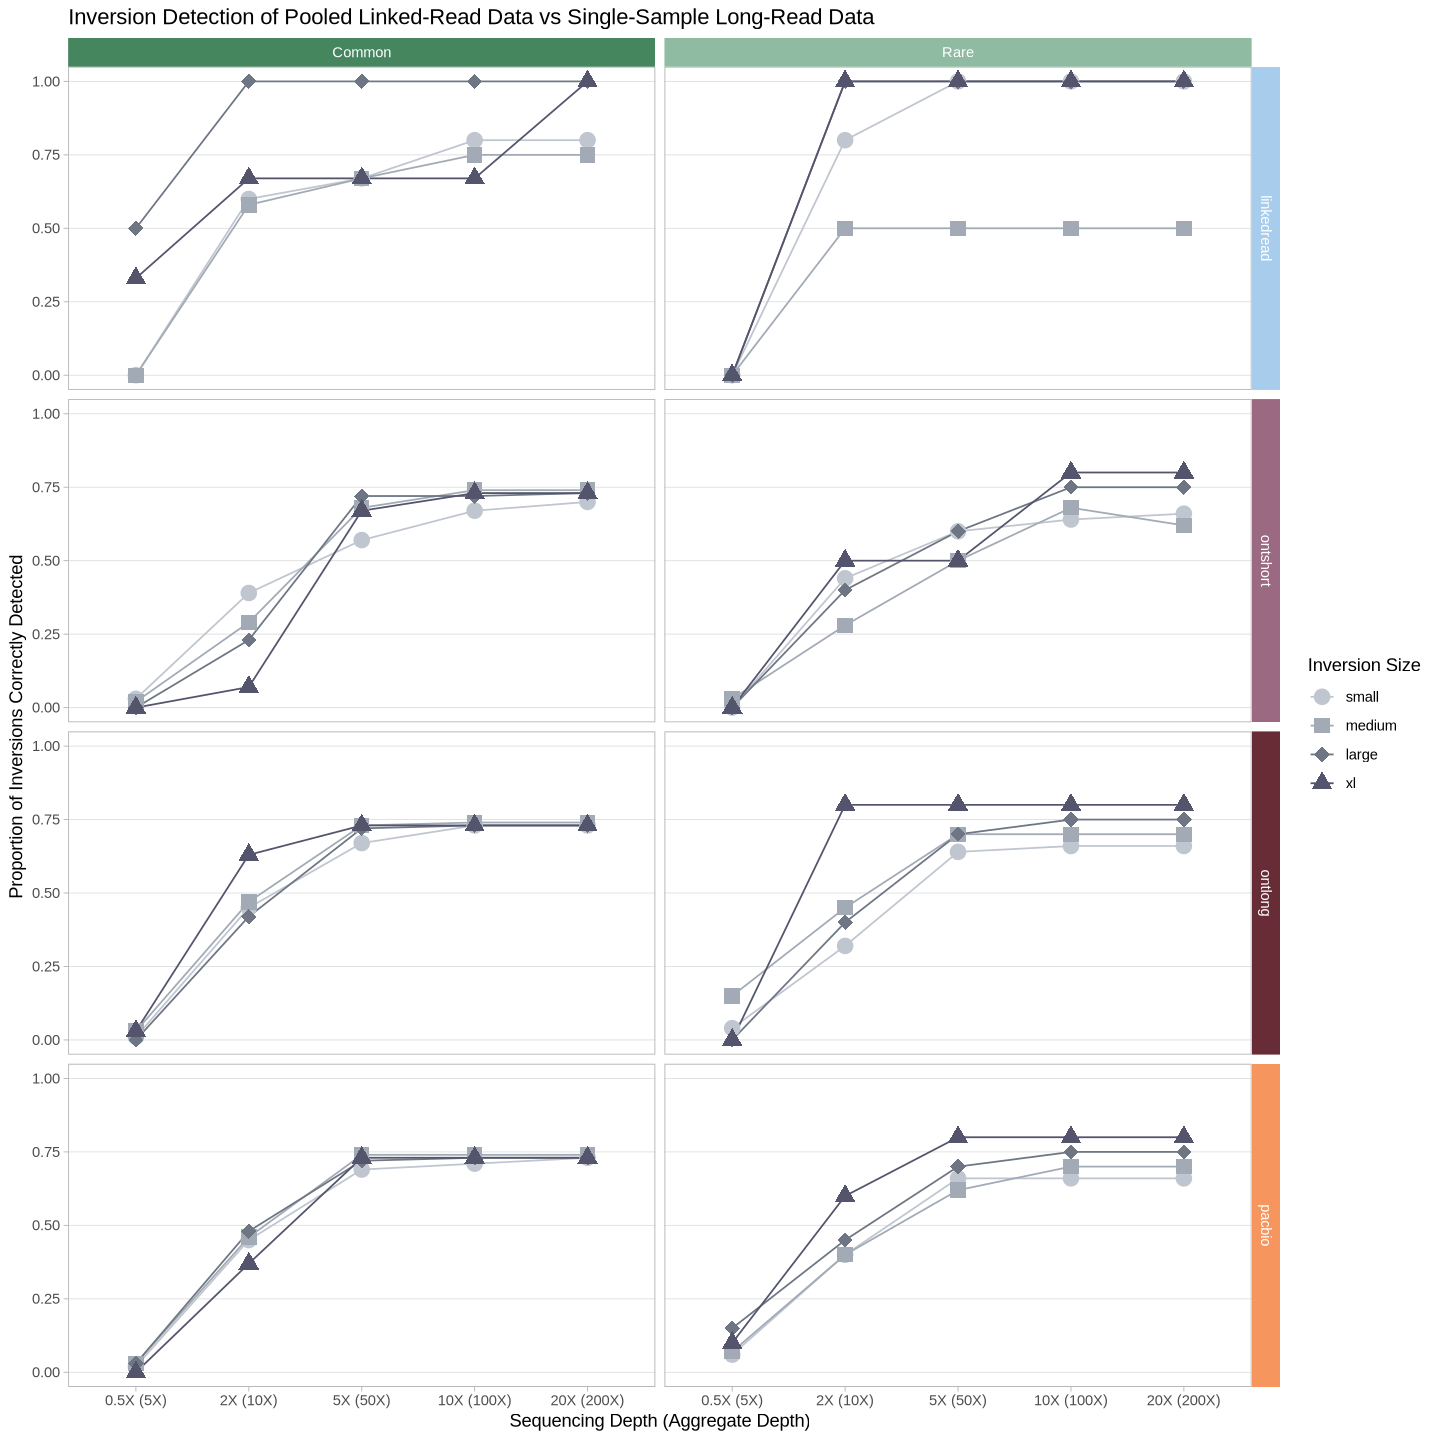

In [50]:
options(repr.plot.width = 12, repr.plot.height = 12)
.strip <- strip_themed(background_x = elem_list_rect(fill = freq_colors), background_y = elem_list_rect(fill = tech_colors[c(4,1,2,3)]))

filter(pooled, assessment == "true positive") %>%
ggplot(aes(x = depth, y = proportion, color = size, group = size, shape = size)) +
    geom_line() +
    geom_point(size = 4) +
    scale_color_manual(values = size_colors) +
    scale_shape_manual(values = c(19,15,18,17)) +
    scale_x_discrete(labels = depth_labels) +
    theme_light() +
    labs(title = "Inversion Detection of Pooled Linked-Read Data vs Single-Sample Long-Read Data", color = "Inversion Size", shape = "Inversion Size") +
    ylab("Proportion of Inversions Correctly Detected") +
    xlab("Sequencing Depth (Aggregate Depth)") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid2(cols = vars(treatment), rows = vars(technology), strip = .strip)

### Split by contigs
The plot below is the same as the one above, but separated out by inversion size class

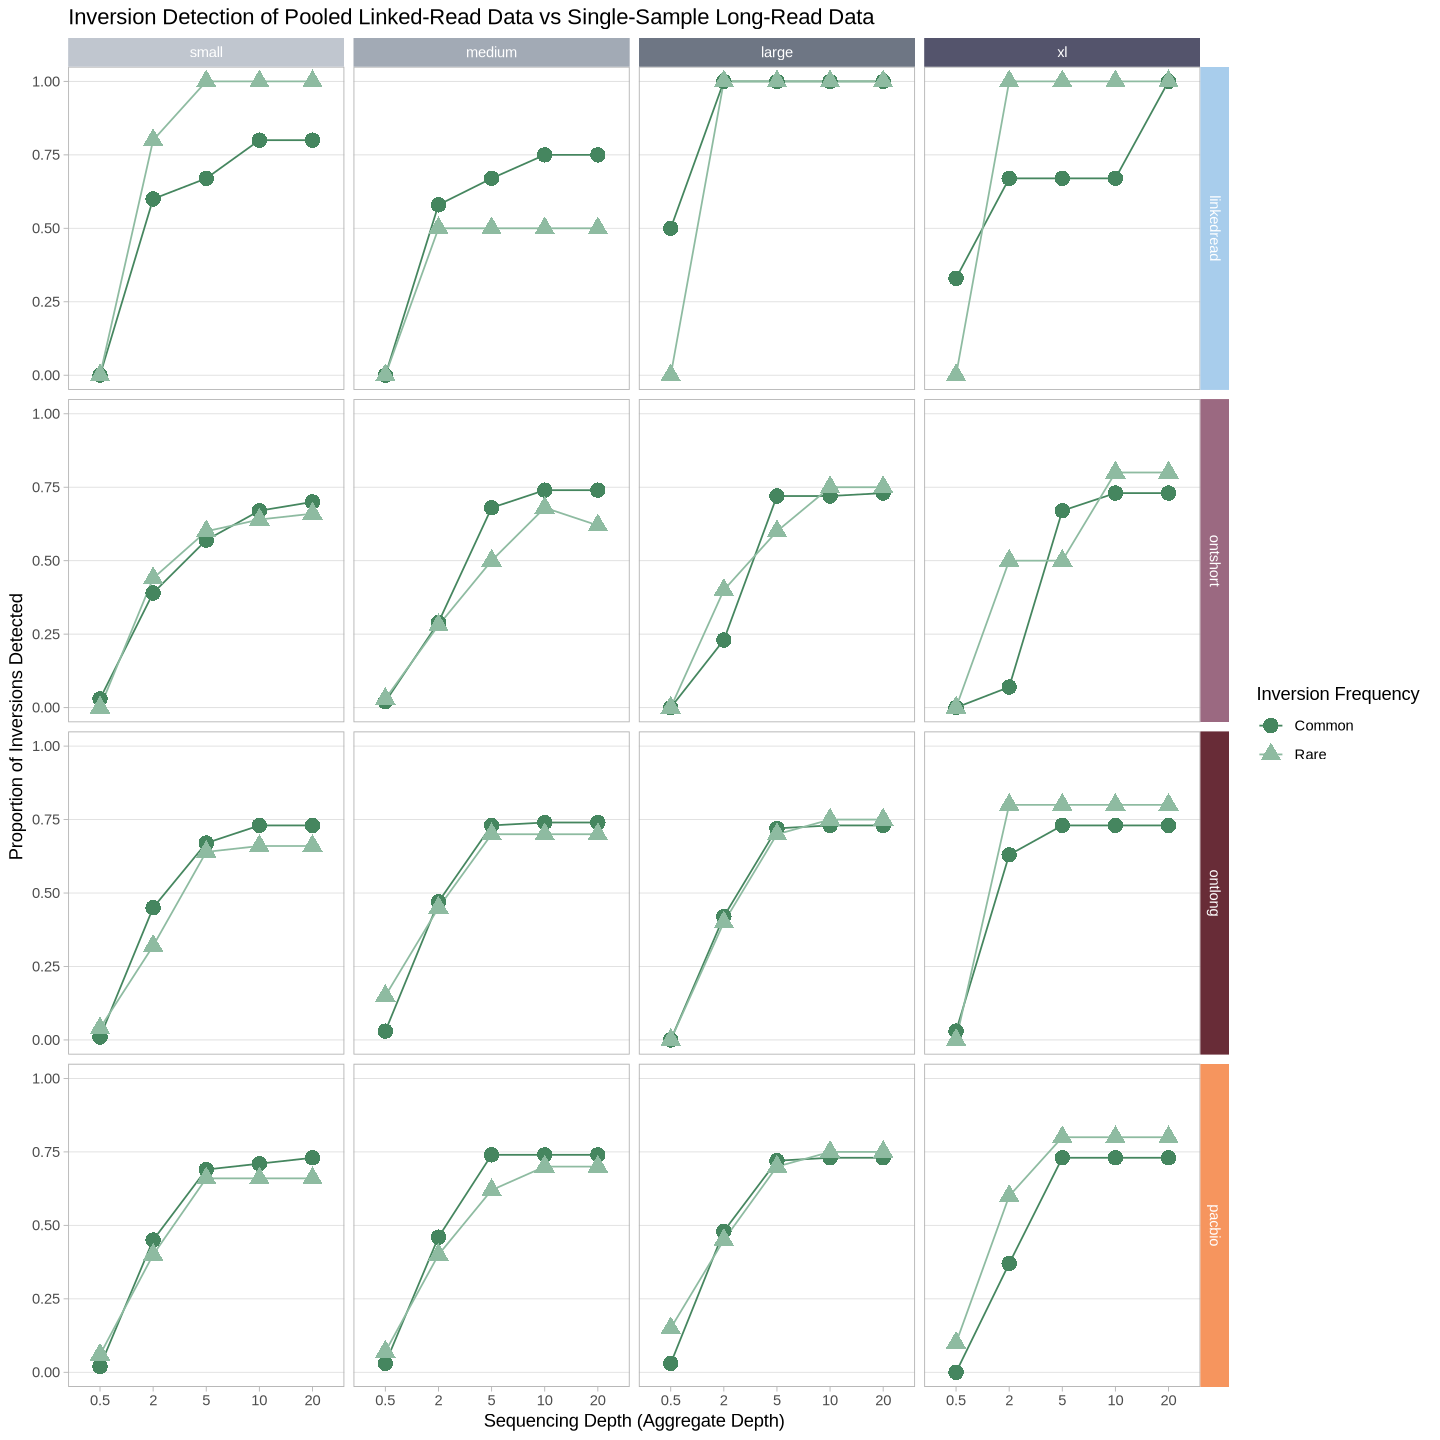

In [51]:
.strip <- strip_themed(background_x = elem_list_rect(fill = size_colors), background_y = elem_list_rect(fill = tech_colors[c(4,1,2,3)]))

filter(pooled, assessment == "true positive") %>%
ggplot(aes(x = depth, y = proportion, color = treatment, shape = treatment, group = treatment)) +
    geom_line() +
    geom_point(size = 4) +
    theme_light() +
    scale_color_manual(values = freq_colors) +
    labs(title = "Inversion Detection of Pooled Linked-Read Data vs Single-Sample Long-Read Data", color = "Inversion Frequency", shape = "Inversion Frequency", size = "Total Inversions") +
    ylab("Proportion of Inversions Detected") +
    xlab("Sequencing Depth (Aggregate Depth)") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid2(cols = vars(size), rows = vars(technology), strip = .strip)